In [1]:
import h5py
from matplotlib import pyplot as plt

In [2]:
f_FCT = h5py.File('fct/celia.h5', 'r')
f = h5py.File('galerkin/celia.h5', 'r')
f_LOW = h5py.File('low-order/celia.h5', 'r')
f_LOWG = h5py.File('low-order-galerkin/celia.h5', 'r')
f_VMS = h5py.File('vms-galerkin/celia.h5', 'r')
f_VMSSC = h5py.File('vms-sc-galerkin/celia.h5', 'r')

elements = f_FCT['elementsSpatial_Domain0'][:]
nodes = f_FCT['nodesSpatial_Domain0'][:]
psi = f_FCT['pressure_head_t0'][:]

elements_G = f['elementsSpatial_Domain0'][:]
nodes_G = f['nodesSpatial_Domain0'][:]
psi_G = f['pressure_head_t0'][:]

elements_LOW = f_LOW['elementsSpatial_Domain0'][:]
nodes_LOW = f_LOW['nodesSpatial_Domain0'][:]
psi_LOW = f_LOW['pressure_head_t0'][:]

elements_LOWG = f_LOWG['elementsSpatial_Domain0'][:]
nodes_LOWG = f_LOWG['nodesSpatial_Domain0'][:]
psi_LOWG = f_LOWG['pressure_head_t0'][:]

elements_VMS = f_VMS['elementsSpatial_Domain0'][:]
nodes_VMS = f_VMS['nodesSpatial_Domain0'][:]
psi_VMS = f_VMS['pressure_head_t0'][:]

elements_VMSSC = f_VMSSC['elementsSpatial_Domain0'][:]
nodes_VMSSC = f_VMSSC['nodesSpatial_Domain0'][:]
psi_VMSSC = f_VMSSC['pressure_head_t0'][:]

In [3]:
import xml.etree.ElementTree as ET
N=0
T=0.0
root = ET.parse('galerkin/celia.xmf').getroot()
for e0 in root.iter('Domain'):
    for e1 in e0.iter('Grid'):
        for e2 in e1.iter('Time'):
            T = float(e2.attrib['Value'])
            N = int(e2.attrib['Name'])
T,N

(0.5, 500)

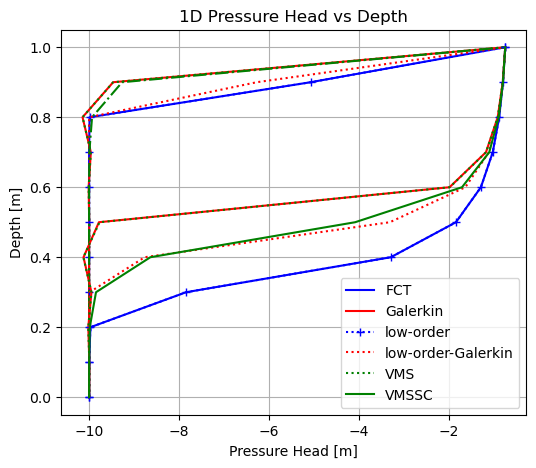

In [4]:
import matplotlib.pyplot as plt

# Pressure head from both FCT and Galerkin solutions
psi5_FCT = f_FCT['pressure_head_t{0}'.format(1)][:]   
psi10_FCT = f_FCT['pressure_head_t{0}'.format(N)][:]  

psi5_G = f['pressure_head_t{0}'.format(1)][:]         
psi10_G = f['pressure_head_t{0}'.format(N)][:]

psi5_LOW = f_LOW['pressure_head_t{0}'.format(1)][:]         
psi10_LOW = f_LOW['pressure_head_t{0}'.format(N)][:]

psi5_LOWG = f_LOWG['pressure_head_t{0}'.format(1)][:]         
psi10_LOWG = f_LOWG['pressure_head_t{0}'.format(N)][:]

psi5_VMS = f_VMS['pressure_head_t{0}'.format(1)][:]         
psi10_VMS = f_VMS['pressure_head_t{0}'.format(N)][:]

psi5_VMSSC = f_VMSSC['pressure_head_t{0}'.format(1)][:]         
psi10_VMSSC = f_VMSSC['pressure_head_t{0}'.format(N)][:]

# Depth coordinates
z_FCT = nodes[:, 0]
z_G = nodes_G[:, 0]


plt.figure(figsize=(6, 5))

plt.plot(psi5_FCT, z_G,'b-')
plt.plot(psi5_G, z_G,'r-')
plt.plot(psi5_LOW, z_G,'b:+')
plt.plot(psi5_LOWG, z_G,'r:')
plt.plot(psi5_VMS, z_G,'g:')
plt.plot(psi5_VMSSC, z_G,'g-.')

plt.plot(psi10_FCT, z_G,'b-', label='FCT')
plt.plot(psi10_G, z_G,'r-',     label='Galerkin')
plt.plot(psi10_LOW, z_G,'b:+',     label='low-order')
plt.plot(psi10_LOWG, z_G,'r:',     label='low-order-Galerkin')
plt.plot(psi10_VMS, z_G,'g:',     label='VMS')
plt.plot(psi10_VMSSC, z_G,'g-',     label='VMSSC')

plt.xlabel('Pressure Head [m]')
plt.ylabel('Depth [m]')
#plt.gca().invert_yaxis()  # Top of column at top of plot
plt.title('1D Pressure Head vs Depth')
plt.legend()
plt.grid(True)
#plt.tight_layout()
plt.savefig('1d_pressure_profiles.png')
plt.show()
